# 🌍 TP Dijkstra – Visualisation des itinéraires mondiaux
# Etudiante
**Maimouna Diallo**   
ID : 300155187  

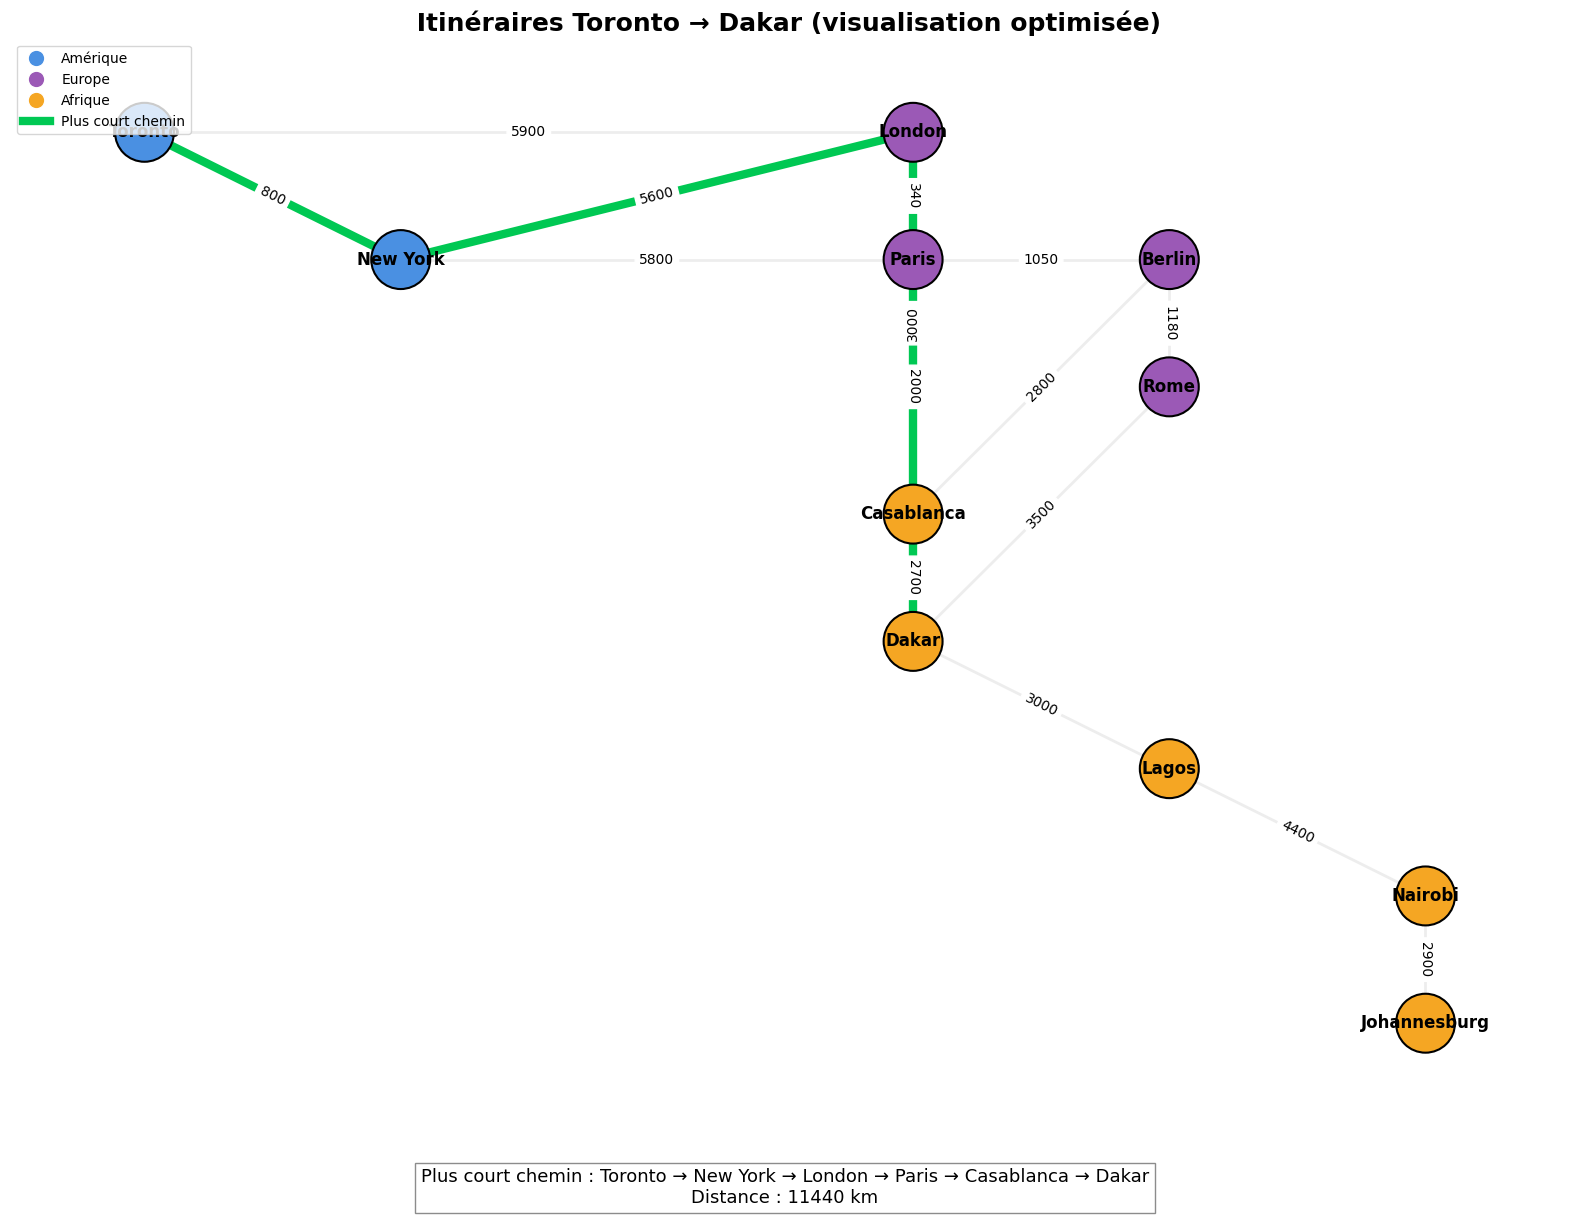

In [36]:
# --- graphe_final_beau.py ---

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from dijkstra_tp import g, dijkstra, shortest, find_all_paths, path_distance

# --- Configuration ---
start_city = 'Toronto'
target_city = 'Dakar'

# --- Calcul Dijkstra ---
start_vertex = g.get_vertex(start_city)
dijkstra(g, start_vertex)

shortest_path = shortest(g.get_vertex(target_city))
dist_short = path_distance(g, shortest_path)

# --- Graphe enrichi ---
edges = [
    ('Toronto','New York',800),
    ('New York','London',5600),
    ('New York','Paris',5800),
    ('Toronto','London',5900),
    ('London','Paris',340),
    ('Paris','Berlin',1050),
    ('Berlin','Rome',1180),
    ('Paris','Casablanca',2000),
    ('London','Casablanca',3000),
    ('Berlin','Casablanca',2800),
    ('Rome','Dakar',3500),
    ('Casablanca','Dakar',2700),
    ('Dakar','Lagos',3000),
    ('Lagos','Nairobi',4400),
    ('Nairobi','Johannesburg',2900),
]

G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# --- Positions MANUELLES (style carte ) ---
pos = {
    'Toronto': (-3, 2),
    'New York': (-2, 1),
    'London': (0, 2),
    'Paris': (0, 1),
    'Berlin': (1, 1),
    'Rome': (1, 0),
    'Casablanca': (0, -1),
    'Dakar': (0, -2),
    'Lagos': (1, -3),
    'Nairobi': (2, -4),
    'Johannesburg': (2, -5)
}

plt.figure(figsize=(20, 14))

# --- Couleurs par continent ---
node_colors = []
for node in G.nodes():
    if node in ['Toronto','New York']:
        node_colors.append('#4A90E2')  # bleu
    elif node in ['London','Paris','Berlin','Rome']:
        node_colors.append('#9B59B6')  # violet
    else:
        node_colors.append('#F5A623')  # orange

# --- Noeuds ---
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1800,
    edgecolors='black',
    linewidths=1.5
)

nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# --- Arêtes de base (très légères) ---
nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=2, alpha=0.4)

# --- Tous les chemins ---
all_paths = find_all_paths(g, start_city, target_city)
all_paths_sorted = sorted(all_paths, key=lambda p: path_distance(g, p))

# --- Dessin des chemins ---
for path in all_paths_sorted:
    edges_path = list(zip(path[:-1], path[1:]))

    if path == shortest_path:
        # 🔥 Chemin optimal
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges_path,
            width=6,
            edge_color='#00C853',  # vert moderne
            alpha=1
        )
    else:
        # chemins secondaires
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges_path,
            width=2,
            edge_color='gray',
            alpha=0.2
        )

# --- Distances ---
edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# --- Info chemin ---
plt.text(
    0.5, -0.08,
    f"Plus court chemin : {' → '.join(shortest_path)}\nDistance : {dist_short} km",
    fontsize=13,
    ha='center',
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray')
)

# --- Légende ---
legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='Amérique', markerfacecolor='#4A90E2', markersize=12),
    Line2D([0],[0], marker='o', color='w', label='Europe', markerfacecolor='#9B59B6', markersize=12),
    Line2D([0],[0], marker='o', color='w', label='Afrique', markerfacecolor='#F5A623', markersize=12),
    Line2D([0],[0], color='#00C853', lw=6, label='Plus court chemin'),
]

plt.legend(handles=legend_elements, loc='upper left')

# --- Titre ---
plt.title(" Itinéraires Toronto → Dakar (visualisation optimisée)", fontsize=18, fontweight='bold')

plt.axis('off')
plt.show()